# Understand size and distribution of contrail-sensitive regions

## 1. Download gridded CoCiP output from contrails.org
- Contrails.org provide global gridded CoCiP outputs via their API (https://apidocs.contrails.org/notebooks/research_api.html)
- Intro to gridded CoCiP: https://py.contrails.org/notebooks/CoCiPGrid.html
- Original publication: https://gmd.copernicus.org/articles/18/253/2025/
- Hourly coverage not complete - around two days are missing despite repeated API requests

## 2. Analyse ISSR distribution

- Take the gridded CoCiP output for every hour
- We take an Airbus A320 as representative aircraft with an engine efficiency of 0.32 and download the grid for the whole globe
- Identify connected regions where the energy forcing in J/m in a given hour is above a given threshold
- This threshold comes from https://gmd.copernicus.org/articles/18/253/2025/
- The grid-based CoCiP defines regions with strongly warming contrails based on the 80th percentile (5×108 J m−1) and the 95th percentile (1.5×109 J m−1) of EFcontrail per flight distance flown, both of which were derived from a 2019 global contrail simulation using the trajectory-based CoCiP (Teoh et al., 2024a).
- We therefore use 5e8 J/m as threshold
- These regions need to lie within the bounding box lon = (-90.0, 40.0) and lat = (30.0, 80.0)
- If they intersect with the bounding box - discard them (this potentially disqualifies regions that stretch into the arctic)
- Compute key stats for every identified region such as mean latitude, longitude, altitude, width, forcing etc. 
- Save all stats to giant list containing the identified regions for all hours 

### Weaknesses of this analysis
- The intersection condition implies that we potentially miss out on very big ISSRs that consistently go to the North pole or have very high longitudinal elongation
- We do not track the evolution of ISSRs over time - in consecutive hours, we consider the same ISSR but don't actually track which ISSRs are the same  - so this is really an analysis about annual average properties of ISSRs rather than a study of how individual ISSRs evolve

## 1. Download gridded CoCiP from contrails.org

In [ ]:
from datetime import datetime, timedelta
from tqdm import tqdm
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
import requests
import requests  # don’t forget to import
from google.colab import userdata
import requests

API_KEY = userdata.get('CONTRAILS_API_KEY')
URL = "https://api.contrails.org"
HEADERS = {"x-api-key": API_KEY}

START_DATE = "2024-01-09"
END_DATE   = "2024-12-31"  # inclusive
OUTDIR = "/content/drive/MyDrive/GriddedCoCip/contrails.org"

os.makedirs(OUTDIR, exist_ok=True)

start_dt = datetime.fromisoformat(START_DATE)
end_dt   = datetime.fromisoformat(END_DATE)

def download_file(dt):
    time_str = dt.strftime("%Y-%m-%dT%H")
    fname = dt.strftime("%Y%m%dT%H") + ".nc"
    outpath = os.path.join(OUTDIR, fname)

    if os.path.exists(outpath):
        return f"Skipped {time_str} (already exists)"

    params = {
        "time": time_str,
        "bbox": "-180,-89,180,89",  # global
        "engine_efficiency": 0.32,
        "aircraft_type": "A320"
    }

    try:
        r = requests.get(f"{URL}/v0/grid/cocip", params=params,
                         headers=HEADERS, timeout=120)
        if r.status_code == 200 and "netcdf" in r.headers.get("content-type", "").lower():
            with open(outpath, "wb") as f:
                f.write(r.content)
            return f"Downloaded {time_str}"
        else:
            return f"Failed {time_str}: {r.status_code} {r.reason}"
    except Exception as e:
        return f"Error {time_str}: {e}"

# Build list of datetimes
all_dts = []
curr_dt = start_dt
while curr_dt <= end_dt:
    for h in range(24):
        all_dts.append(curr_dt + timedelta(hours=h))
    curr_dt += timedelta(days=1)

# Run in parallel (tune workers to avoid server overload)
with ThreadPoolExecutor(max_workers=5) as executor:
    futures = [executor.submit(download_file, dt) for dt in all_dts]
    for future in as_completed(futures):
        print(future.result())

## File availability

In [6]:
import os
import re
import pandas as pd
from datetime import datetime

# --- CONFIG ---
FOLDER_PATH = r"G:\.shortcut-targets-by-id\10bix0f5QiOF3GSGl4hyO16V5buUcN1uP\GriddedCoCip\contrails.org"
OUTPUT_CSV = "output/issr/1_daily_nc_availability.csv"

# --- MAIN SCRIPT ---
pattern = re.compile(r"(\d{8})T(\d{2}).nc$")

# Dictionary to store available hours per day
availability = {}

for filename in os.listdir(FOLDER_PATH):
    if filename.endswith(".nc"):
        match = pattern.search(filename)
        if not match:
            continue

        date_str, hour  = match.groups()
        date = datetime.strptime(date_str, "%Y%m%d").date()

        # Record availability for that hour
        availability.setdefault(date, set()).add(int(hour))

# Build a list of rows for the CSV
rows = []
for date, hours in sorted(availability.items()):
    total_hours_available = len(hours)
    share = total_hours_available / 24  # Share of day covered
    rows.append({
        "date": date,
        "filename_pattern": f"{date.strftime('%Y%m%d')}-*-*-contrail.nc",
        "availability_share": round(share, 3)
    })

# Convert to DataFrame and save
df = pd.DataFrame(rows)
df.to_csv(OUTPUT_CSV, index=False)

print(f"✅ Wrote {OUTPUT_CSV} with {len(df)} days of data.")


✅ Wrote output/issr/1_daily_nc_availability.csv with 366 days of data.


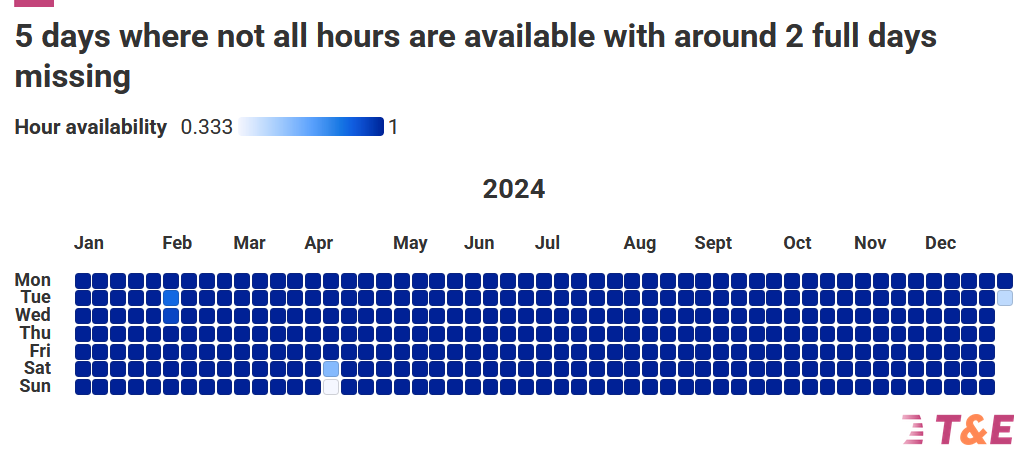

## 2. Visualise ISSRs at two different times
- This shows their scale and how fast they move

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm

def plot_map(ds, var="seg_length_km", vmin=None, vmax=None, savepath=None):
    """
    Plot a 2D map of the given variable from an xarray Dataset.
    Assumes dimensions: (flight_level, latitude, longitude).
    Sums over flight levels before plotting.
    """

    # --- Select single flight level (or sum if you want) ---
    data_2d = ds[var].sel(flight_level=360).squeeze()

    lon = ds.longitude.values
    lat = ds.latitude.values

    proj = ccrs.PlateCarree()

    # --- Define discrete color map ---
    # Boundaries define the edges of color intervals
    boundaries = [-1e15, -1e5, 1e5, 5e8, 1e15]
    # Colors for each interval
    colors = ['#75a1f4', 'white', '#ff8754', '#c2447a']
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(boundaries, cmap.N, clip=True)

    # --- Setup map ---
    fig, ax = plt.subplots(
        subplot_kw={"projection": proj},
        figsize=(7.94 * 2, 5.75 * 2)
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="white")
    ax.add_feature(cfeature.OCEAN, facecolor="white")

    # --- Plot data ---
    im = ax.imshow(
        data_2d.T,
        origin="lower",
        cmap=cmap,
        norm=norm,
        transform=proj,
        extent=[lon.min(), lon.max(), lat.min(), lat.max()],
    )

    plt.axis('off')
    # --- Save to PNG ---
    if savepath:
        plt.savefig(savepath, bbox_inches="tight", pad_inches=0)

    plt.show()

import pandas as pd 

# These definitions follow the bounding boxes in Teoh et al.'s paper (except for Eurocontrol)
regions = {
    "Global": {"lon_min": -180, "lon_max": 180, "lat_min": -90, "lat_max": 90},
    "USA": {"lon_min": -126, "lon_max": -66, "lat_min": 23, "lat_max": 50},
    "Europe": {"lon_min": -12, "lon_max": 20, "lat_min": 35, "lat_max": 60},
    "Eurocontrol": {"lon_min": -30.0, "lon_max": 45.0, "lat_min": 25.0, "lat_max": 72.0},
    "Eurocontrol + North Atlantic": {"lon_min": -70.0, "lon_max": 45.0, "lat_min": 25.0, "lat_max": 72.0},
    "East_Asia": {"lon_min": 103, "lon_max": 150, "lat_min": 15, "lat_max": 48},
    "Southeast_Asia": {"lon_min": 87.5, "lon_max": 130, "lat_min": -10, "lat_max": 20},
    "Latin_America": {"lon_min": -85, "lon_max": -35, "lat_min": -60, "lat_max": 15},
    "Africa_Middle_East": {"lon_min": -20, "lon_max": 50, "lat_min": -35, "lat_max": 40},
    "China": {"lon_min": 73.5, "lon_max": 135, "lat_min": 18, "lat_max": 53.5},
    "India": {"lon_min": 68, "lon_max": 97.5, "lat_min": 8, "lat_max": 35.5},
    "North Atlantic": {"lon_min": -70, "lon_max": -5, "lat_min": 40, "lat_max": 63},
    "North Pacific": {"lon_min": 140, "lon_max": -120, "lat_min": 35, "lat_max": 65},
    "Arctic": {"lon_min": -180, "lon_max": 180, "lat_min": 66.5, "lat_max": 90}, 
}

def subset_region(ds, region):
    """Return subset of dataset within the region bounding box."""
    lon_min, lon_max = region["lon_min"], region["lon_max"]
    lat_min, lat_max = region["lat_min"], region["lat_max"]

    # Handle longitude wrap-around (e.g. North Pacific)
    if lon_min < lon_max:
        subset = ds.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max))
    else:
        # For regions crossing the dateline (e.g. 140E–120W)
        subset1 = ds.sel(longitude=slice(lon_min, 180))
        subset2 = ds.sel(longitude=slice(-180, lon_max))
        subset = xr.concat([subset1, subset2], dim="longitude")
        subset = subset.sel(latitude=slice(lat_min, lat_max))
    
    return subset

In [3]:
import xarray as xr 
ds = xr.open_dataset(r"data\issr\20240101T00.nc")
ds

C:\Users\TE\AppData\Local\Temp\ipykernel_111404\2101224907.py:2: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(r"data\issr\20240101T00.nc")


<xarray.Dataset> Size: 199MB
Dimensions:       (longitude: 1440, latitude: 641, flight_level: 18, time: 1)
Coordinates:
  * longitude     (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * latitude      (latitude) float32 3kB -80.0 -79.75 -79.5 ... 79.5 79.75 80.0
  * flight_level  (flight_level) int32 72B 270 280 290 300 ... 410 420 430 440
  * time          (time) datetime64[ns] 8B 2024-01-01
Data variables:
    ef_per_m      (longitude, latitude, flight_level, time) float32 66MB ...
    contrail_age  (longitude, latitude, flight_level, time) timedelta64[ns] 133MB ...
Attributes:
    met_source_provider:       ECMWF
    met_source_dataset:        ERA5
    met_source_product:        reanalysis
    name:                      cocip
    aircraft_type:             A320
    cocip_max_contrail_age:    12 hours
    cocip_dt_integration:      5 minutes
    humidity_scaling_name:     exponential_boost_latitude_customization
    humidity_scaling_formula:  rhi -> (rhi / rhi_adj) ^ rhi_boost_exponent
    pycontrails_version:       0.32.2

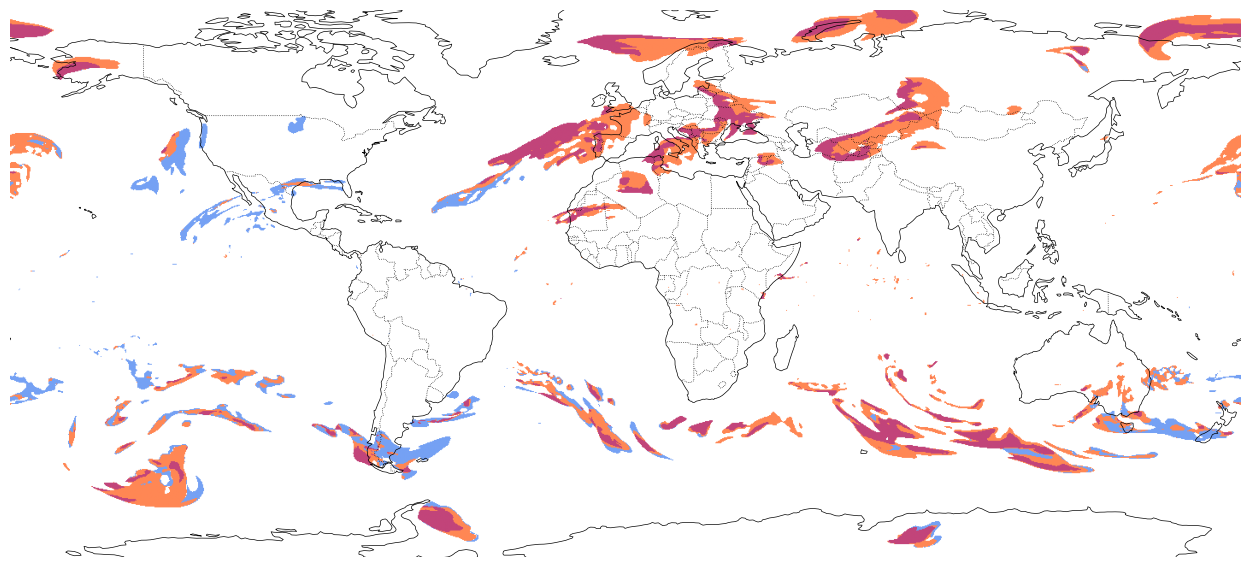

In [62]:

plot_map(ds, var="ef_per_m")

C:\Users\TE\AppData\Local\Temp\ipykernel_111404\400760449.py:3: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(file)


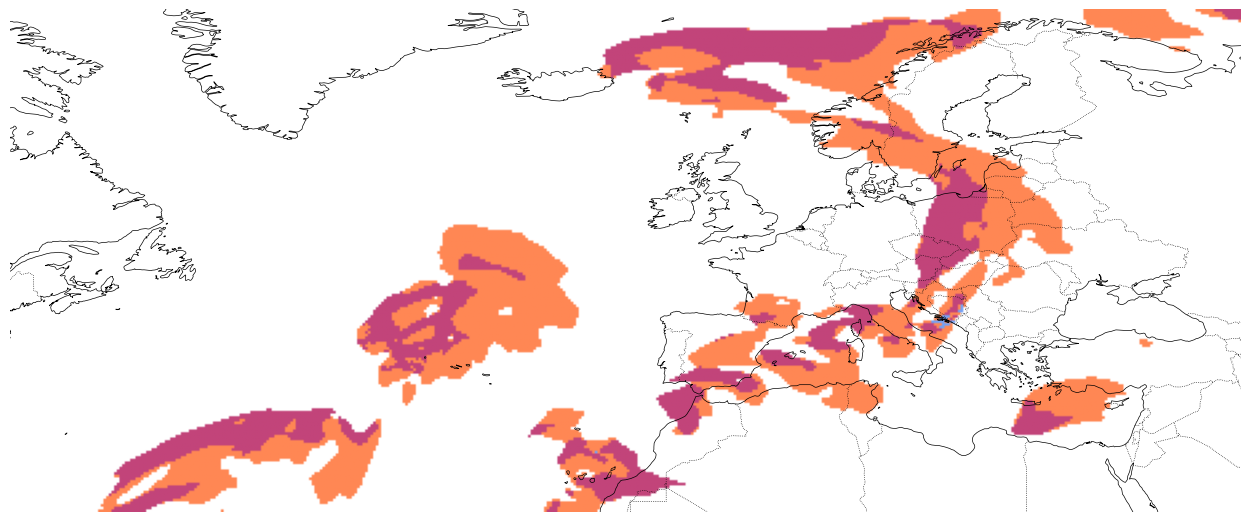

C:\Users\TE\AppData\Local\Temp\ipykernel_111404\400760449.py:3: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(file)


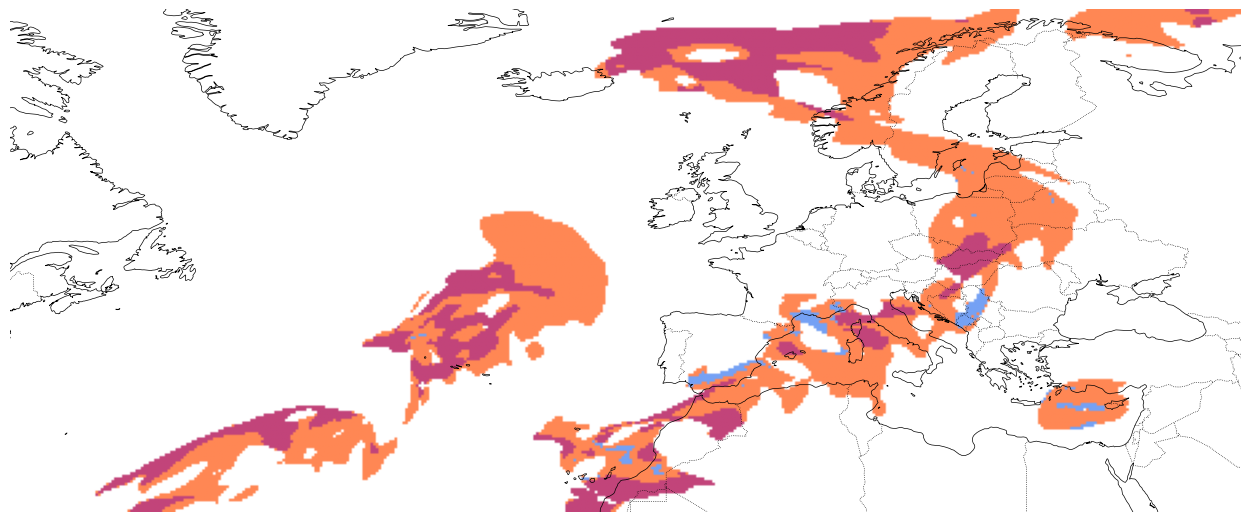

C:\Users\TE\AppData\Local\Temp\ipykernel_111404\400760449.py:3: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(file)


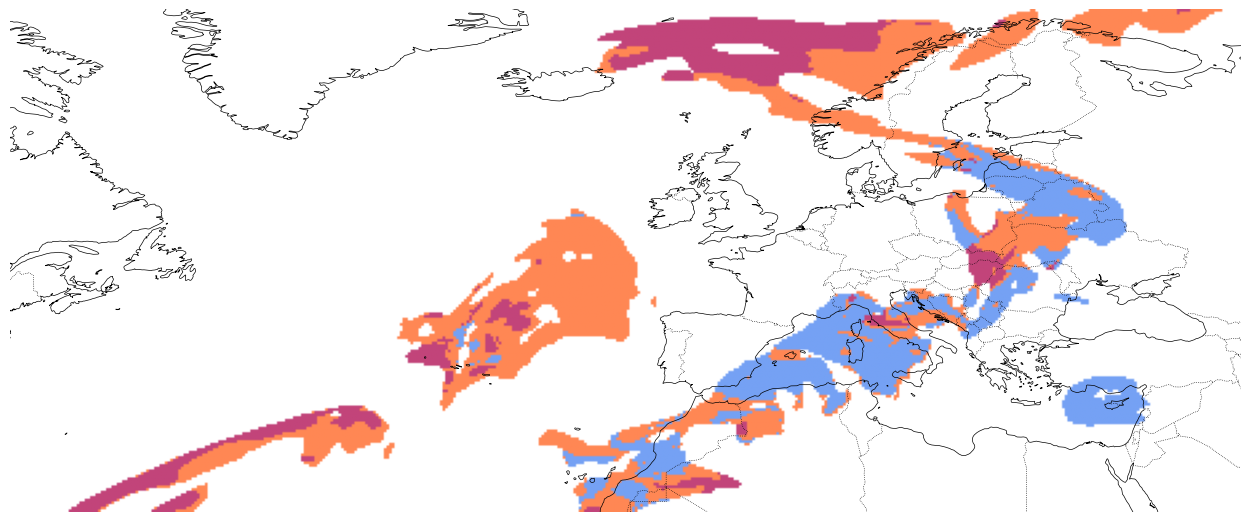

C:\Users\TE\AppData\Local\Temp\ipykernel_111404\400760449.py:3: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(file)


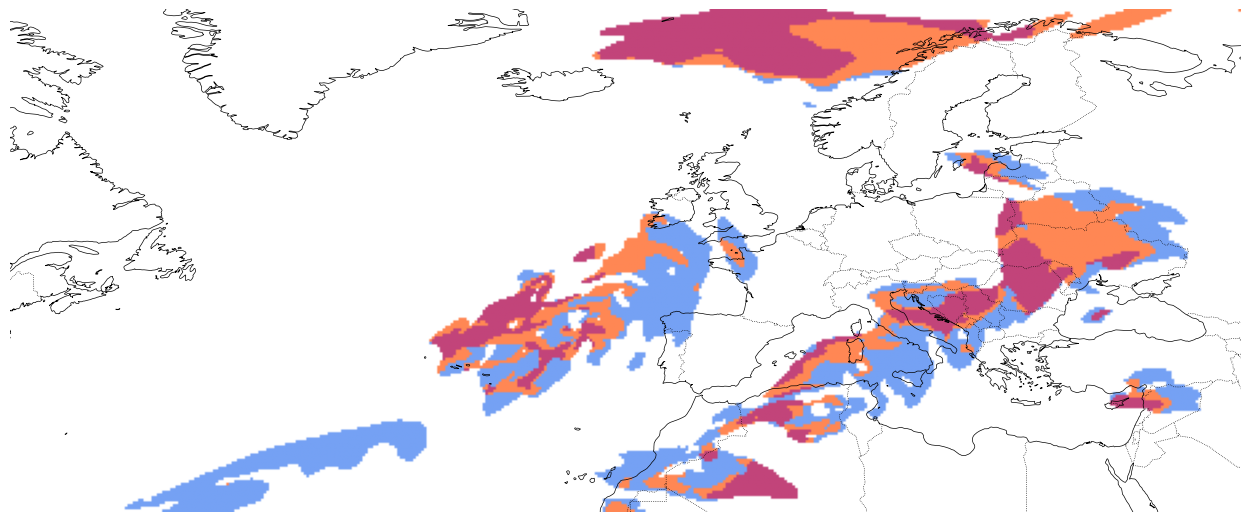

In [64]:
import xarray as xr 
for file in [r"data\issr\20240101T00.nc", r"data\issr\20240101T03.nc", r"data\issr\20240101T06.nc", r"data\issr\20240101T12.nc"]:
    ds = xr.open_dataset(file)
    plot_map(subset_region(ds, regions["Eurocontrol + North Atlantic"]), var="ef_per_m", vmin=0, vmax=1e9, savepath="output/forcing/2_issr_map.png")

C:\Users\TE\AppData\Local\Temp\ipykernel_111404\1188982217.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


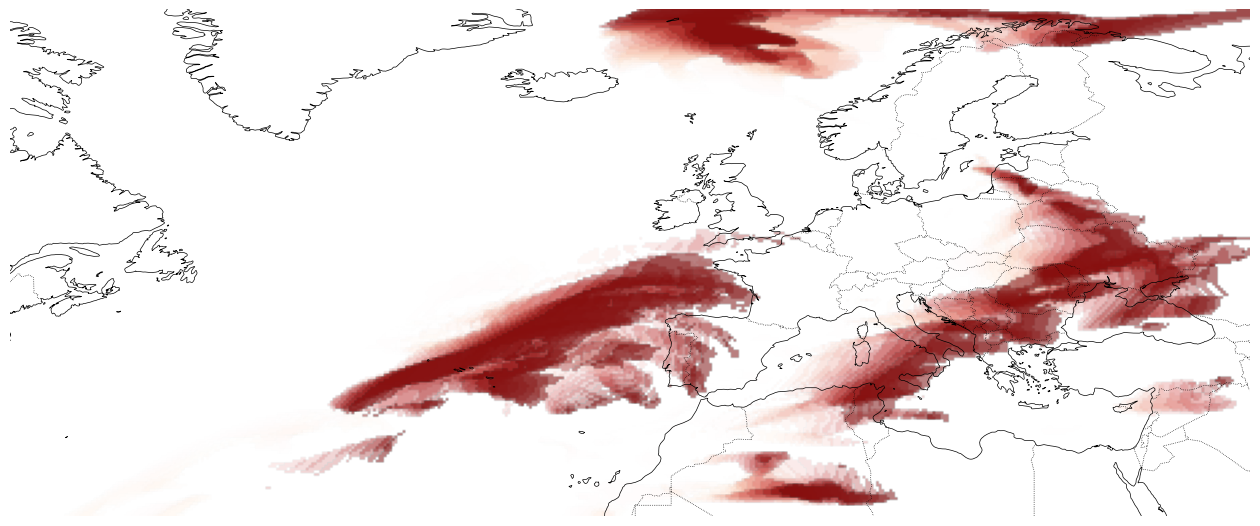

In [47]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from scipy.ndimage import gaussian_filter

def plot_motion_trails(datasets, var="ef_per_m", threshold=5e8, blur_sigma=3, alpha_decay=0.6, savepath=None):
    """
    Plot ISSR motion trails from a sequence of xarray Datasets.
    
    Parameters
    ----------
    datasets : list of xarray.Dataset
        Sequential datasets representing ISSR states.
    var : str
        Variable name to plot.
    threshold : float
        Minimum value to visualize (all below set to NaN).
    blur_sigma : float
        Strength of Gaussian blur for motion effect.
    alpha_decay : float
        Transparency factor for each older layer (0–1).
    savepath : str, optional
        Path to save final figure.
    """
    # --- Setup base map ---
    ds0 = datasets[0]
    lon = ds0.longitude.values
    lat = ds0.latitude.values
    proj = ccrs.PlateCarree()

    fig, ax = plt.subplots(subplot_kw={"projection": proj}, figsize=(16, 11))
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="white")
    ax.add_feature(cfeature.OCEAN, facecolor="white")

    # --- Colormap setup ---
    cmap_name = "gist_heat_r"
    cmap = cm.get_cmap(cmap_name)
    norm = mcolors.Normalize(vmin=0, vmax=len(datasets)-1 + 10)

    # --- Plot each dataset with decreasing alpha (newest = strongest) ---
    n = len(datasets)
    for i, ds in enumerate(datasets):
        data_2d = ds[var].sel(flight_level=360).squeeze().values
        data_2d = np.where(data_2d > threshold, 1.0, np.nan)  # binary mask
        trail_intensity = gaussian_filter(data_2d, sigma=blur_sigma)  # blur
        
        alpha = 0.5 * (alpha_decay ** (n - i - 1))  # older = fainter
        color = cmap(norm(i))
        ax.imshow(
            trail_intensity.T,
            origin="lower",
            alpha=alpha,            
            cmap=mcolors.ListedColormap([color]),
            transform=proj,
            extent=[lon.min(), lon.max(), lat.min(), lat.max()]
        )

    plt.axis("off")

    if savepath:
        plt.savefig(savepath, bbox_inches="tight", pad_inches=0, dpi=300)
    plt.show()
plot_motion_trails(datasets, blur_sigma=0, alpha_decay=0.8)


## 2. Analyse ISSR distribution


In [95]:
import numpy as np
import pandas as pd
import shapely
import xarray as xr
import regionmask
from scipy import ndimage
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import glob
import os

# ---------------------------------------
# CONFIGURATION
# ---------------------------------------
input_pattern = "2024*.nc"
output_file = "contrail_region_details_2024.csv"
n_workers = os.cpu_count() - 2  # use all but two cores

# European airspace bounding box - this is a very generous bounding box that also includes parts of North America
bbox = shapely.geometry.box(-180.0, -90.0, 180.0, 90.0)
mask_reg = regionmask.Regions([bbox])

R = 6371.0  # Earth radius in km
big_hit_region_threshold = 5 * 1e8 # J/m

# ---------------------------------------
# HELPER FUNCTION
# ---------------------------------------
def process_file(filepath):
    """Process one hourly CoCiP file and return region-level metrics."""
    try:
        ds = xr.open_dataset(filepath)
        ds_hr = ds.isel(time=0)
        ef = ds_hr["ef_per_m"].transpose("latitude", "longitude", "flight_level")
        lat = ef.latitude.values
        lon = ef.longitude.values
        lev = ef.flight_level.values
        time = pd.to_datetime(str(ds.time.values[0]))

        # European airspace mask
        mask2d = mask_reg.mask(lon, lat)
        ecac_mask_2d = np.isfinite(mask2d.values)
        ecac_mask_3d = np.repeat(ecac_mask_2d[:, :, None], ef.shape[2], axis=2)

        # Area grid

        # Ensure that lat-long grid is regular
        assert(np.diff(lat).min() == np.diff(lat).max())
        assert(np.diff(lon).min() == np.diff(lon).max())

        # Get grid spacing in radians
        dlat = np.deg2rad(np.abs(np.diff(lat)).mean())
        dlon = np.deg2rad(np.abs(np.diff(lon)).mean())
        lat_rad = np.deg2rad(lat)

        # Approximate latitude dependent area of a single cell
        cell_area_lat = (R**2) * dlat * dlon * np.cos(lat_rad)

        # Create 3D array that contain grid cell array
        area_2d = np.repeat(cell_area_lat[:, None], len(lon), axis=1)
        area_3d = np.repeat(area_2d[:, :, None], ef.shape[2], axis=2)

        # Flight level heights (m)
        # Approximate that 1 feet = 0.3048 (even though this is barometric altitude)
        fl_ft = lev * 100.0
        fl_m = fl_ft * 0.3048
        lev_heights_m = fl_m

        # Positive forcing inside 
        pos_mask_3d = (ef.values > big_hit_region_threshold) & ecac_mask_3d
        pos_mask_3d = np.where(np.isnan(ef.values), False, pos_mask_3d)
                
        structure = ndimage.generate_binary_structure(rank=3, connectivity=1)
        
        # Standard labeling
        # labeled_3d is a 3D array where regions below the threshold are 0 and all connected regions
        # get the same numerical label, n_label is the number of labels = number of ISSRs
        labeled_3d, n_labels = ndimage.label(pos_mask_3d, structure=structure)
        if n_labels == 0:
            return pd.DataFrame([])

        # Discard regions that touch the boundary
        valid_mask = ecac_mask_3d.astype(bool)

        # boundary mask: edges
        boundary = np.zeros_like(valid_mask, dtype=bool)
        boundary[0, :, :]  = True
        boundary[-1, :, :] = True
        boundary[:, 0, :]  = True
        boundary[:, -1, :] = True
        boundary[:, :, 0]  = True
        boundary[:, :, -1] = True

        # Add internal holes (adjacent to invalids) to boundary mask
        eroded = ndimage.binary_erosion(valid_mask, structure=structure, border_value=0)
        boundary |= valid_mask & ~eroded

        # Get a list of labels that touch the boundary to discard them
        boundary_labels = np.unique(labeled_3d[boundary])
        boundary_labels = boundary_labels[boundary_labels > 0]

        print("Number of labels that touch the boundary: ", len(boundary_labels))

        # Keep only interior labels
        all_labels = np.unique(labeled_3d)
        all_labels = all_labels[all_labels > 0]
        print("Number of labels: ", len(all_labels))
        interior_labels = np.setdiff1d(all_labels, boundary_labels)

        # Restrict the labeling to interior regions
        mask_interior = np.isin(labeled_3d, interior_labels)
        print("Number of interior labels: ", len(interior_labels))
        labeled_3d[~mask_interior] = 0
        n_labels = len(interior_labels)
            
        indices = np.unique(labeled_3d)
        ef_vals = np.where(pos_mask_3d, ef.values, np.nan)

        # Prepare coordinate grids
        LAT2D, LON2D = np.meshgrid(lat, lon, indexing="ij")
        LAT3D = np.repeat(LAT2D[:, :, None], ef.shape[2], axis=2)
        LON3D = np.repeat(LON2D[:, :, None], ef.shape[2], axis=2)

        # Compute per-region stats
        region_records = []
        for lab in indices:
            mask = (labeled_3d == lab)
            if not np.any(mask) or lab == 0:
                continue

            weights = area_3d[mask]
            lat_pts = LAT3D[mask]
            lon_pts = LON3D[mask]


            # Lat/Lon centroid (area-weighted)
            weights = area_3d[mask]
            lat_mean = np.average(LAT3D[mask], weights=weights)
            
            # Circular mean of longitude (in radians)
            # The key concern here is to ensure that this is invariant
            # under the choice of longitudinal coordinate system
            lon_rad = np.deg2rad(lon_pts)
            lon_mean_rad = np.arctan2(
                np.average(np.sin(lon_rad), weights=weights),
                np.average(np.cos(lon_rad), weights=weights)
            )
            lon_mean = np.degrees(lon_mean_rad)
            
            
            # Lateral extent
            # Area grid and grid spacing
            dlat = np.abs(np.diff(lat)).mean()          # degrees
            dlon = np.abs(np.diff(lon)).mean()          # degrees
            
            # Forcing
            ef_std  = np.nanstd (ef_vals[mask])
            ef_mean = np.nanmean(ef_vals[mask])
            ef_max  = np.nanmax (ef_vals[mask])

            # Flight level (mean) and thickness
            levels_present = np.any(np.any(mask, axis=0), axis=0)
            lev_ids = np.where(levels_present)[0]
            if len(lev_ids) == 0:
                continue
            
            dz = np.mean(np.diff(lev_heights_m)) if len(lev_heights_m) > 1 else 0
            zmin = lev_heights_m[lev_ids].min()
            zmax = lev_heights_m[lev_ids].max()

            # Compute thickness of flight level
            thickness_m   = zmax - zmin + dz
            thickness_std = np.std(lev_heights_m[lev_ids])
            mean_FL = np.mean(lev[lev_ids])

            
            # Area (km²)
            area_km2 = np.nansum(area_3d[mask])
            # Volume (km^3)
            volume_km3 = area_km2 * thickness_m / 1000

            # Save region record
            region_records.append({
                "time":          time,
                "file":          os.path.basename(filepath),
                "region_id":     lab,
                "area_km2":      area_km2,
                "pt in mask":    mask.sum(),
                "vol_km3":       volume_km3,
                "thickness_m":   thickness_m,
                "std_thickness": thickness_std,
                "mean_FL":       mean_FL,
                "mean_lat":      lat_mean,
                "mean_lon":      lon_mean,
                "mean_forcing":  ef_mean,
                "max_forcing":   ef_max,
                "std_forcing":   ef_std,
            })

        ds.close()
        return pd.DataFrame(region_records), labeled_3d, n_labels

    except Exception as e:
        print(f"⚠️ Error processing {filepath}: {e}")
        return pd.DataFrame([])

In [ ]:
  
import traceback

# ---------------------------------------
# MAIN EXECUTION BLOCK 
# This execution block has some features for restarting a run if it fails
# It also performs regular saves
# Running this with 30 cores takes around 24h
# ---------------------------------------
def main():
    files = sorted(glob.glob(input_pattern))
    print(f"Found {len(files)} hourly files.")
    if not files:
        print("⚠️ No files matched the pattern.")
        return

    # --- optional: resume capability ---
    if os.path.exists(output_file):
        existing = pd.read_csv(output_file)
        done_files = set(existing["file"].unique())
        files = [f for f in files if os.path.basename(f) not in done_files]
        all_dfs = [existing]
        print(f"Resuming from previous run: {len(done_files)} already processed.")
    else:
        all_dfs = []
        done_files = set()

    n_total = len(files)
    if n_total == 0:
        print("✅ All files already processed.")
        return

    # --- partial save configuration ---
    save_every = 20  # save every N files
    temp_file = output_file.replace(".csv", "_partial.csv")

    try:
        with ProcessPoolExecutor(max_workers=n_workers) as executor:
            futures = {executor.submit(process_file, f): f for f in files}
            processed = 0

            for fut in tqdm(as_completed(futures), total=n_total, desc="Processing files"):
                filepath = futures[fut]
                try:
                    df_part, _, _ = fut.result()
                    if not df_part.empty:
                        all_dfs.append(df_part)
                        done_files.add(os.path.basename(filepath))
                except Exception as e:
                    print(f"⚠️ Failure in {filepath}: {e}")
                    traceback.print_exc(limit=1)
                    continue

                processed += 1
                # --- periodic save ---
                if processed % save_every == 0:
                    try:
                        df_temp = pd.concat(all_dfs, ignore_index=True)
                        df_temp.to_csv(temp_file, index=False)
                        print(f"💾 Saved interim results ({processed}/{n_total}) to {temp_file}")
                    except Exception as e:
                        print(f"⚠️ Could not save interim CSV: {e}")

    except KeyboardInterrupt:
        print("\n⛔ Interrupted by user. Saving current progress...")
    except Exception as e:
        print(f"❌ Unexpected error in main loop: {e}")
    finally:
        # --- final save ---
        if all_dfs:
            df_final = pd.concat(all_dfs, ignore_index=True)
            df_final.to_csv(output_file, index=False)
            print(f"✅ Saved {len(df_final)} total region records to {output_file}")
        else:
            print("⚠️ No valid data processed (nothing to save).")



# ---------------------------------------
# ENTRY POINT (required for multiprocessing)
# ---------------------------------------
if __name__ == "__main__":
    main()

## 2 b. Test algorithm for one hour

In [96]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

filepath = "data/issr/20240101T00.nc"
ds = xr.open_dataset(filepath)
df, labeled_3d, n_labels = process_file(filepath)


C:\Users\TE\AppData\Local\Temp\ipykernel_101688\2520059127.py:6: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(filepath)
C:\Users\TE\AppData\Local\Temp\ipykernel_101688\3555100311.py:32: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default wa

Number of labels that touch the boundary:  447
Number of labels:  1603
Number of interior labels:  1156


In [97]:
df

,time,file,region_id,area_km2,pt in mask,vol_km3,thickness_m,std_thickness,mean_FL,mean_lat,mean_lon,mean_forcing,max_forcing,std_forcing
0,2024-01-01,20240101T00.nc,7,1.408260e+02,1,4.292378e+01,304.8,0.000000,280.0,-79.500000,-104.500000,5.035129e+08,5.035129e+08,0.000000e+00
1,2024-01-01,20240101T00.nc,9,5.898057e+02,4,1.797728e+02,304.8,0.000000,280.0,-79.000000,-116.374985,5.146178e+08,5.298120e+08,1.060446e+07
2,2024-01-01,20240101T00.nc,10,1.474514e+02,1,4.494319e+01,304.8,0.000000,320.0,-79.000000,-72.999992,5.003984e+08,5.003984e+08,0.000000e+00
3,2024-01-01,20240101T00.nc,14,1.623301e+04,98,4.947821e+03,304.8,0.000000,300.0,-77.615440,33.619698,5.627470e+08,6.630622e+08,4.576658e+07
4,2024-01-01,20240101T00.nc,19,9.738968e+02,6,2.968437e+02,304.8,0.000000,280.0,-77.873734,-96.499992,5.162659e+08,5.289011e+08,7.073463e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1151,2024-01-01,20240101T00.nc,1586,3.235275e+02,1,9.861118e+01,304.8,0.000000,330.0,65.250000,-13.750000,1.423463e+09,1.423463e+09,0.000000e+00
1152,2024-01-01,20240101T00.nc,1591,1.830276e+03,6,5.578682e+02,304.8,0.000000,340.0,66.750008,-177.624985,6.501012e+08,7.211261e+08,7.580712e+07
1153,2024-01-01,20240101T00.nc,1593,2.427965e+03,8,7.400437e+02,304.8,0.000000,370.0,66.874359,7.376278,5.634784e+08,6.014905e+08,2.354047e+07
1154,2024-01-01,20240101T00.nc,1594,8.684537e+02,3,2.647047e+02,304.8,0.000000,290.0,68.000000,-9.249999,5.267075e+08,5.342298e+08,1.036265e+07


In [93]:
n_labels, len(np.unique(labeled_3d))

(88, 89)

In [63]:
ds

<xarray.Dataset> Size: 199MB
Dimensions:       (longitude: 1440, latitude: 641, flight_level: 18, time: 1)
Coordinates:
  * longitude     (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * latitude      (latitude) float32 3kB -80.0 -79.75 -79.5 ... 79.5 79.75 80.0
  * flight_level  (flight_level) int32 72B 270 280 290 300 ... 410 420 430 440
  * time          (time) datetime64[ns] 8B 2024-01-01
Data variables:
    ef_per_m      (longitude, latitude, flight_level, time) float32 66MB 0.0 ...
    contrail_age  (longitude, latitude, flight_level, time) timedelta64[ns] 133MB ...
Attributes:
    met_source_provider:       ECMWF
    met_source_dataset:        ERA5
    met_source_product:        reanalysis
    name:                      cocip
    aircraft_type:             A320
    cocip_max_contrail_age:    12 hours
    cocip_dt_integration:      5 minutes
    humidity_scaling_name:     exponential_boost_latitude_customization
    humidity_scaling_formula:  rhi -> (rhi / rhi_adj) ^ rhi_boost_exponent
    pycontrails_version:       0.32.2

<xarray.DataArray 'longitude' ()> Size: 4B
array(-180., dtype=float32)

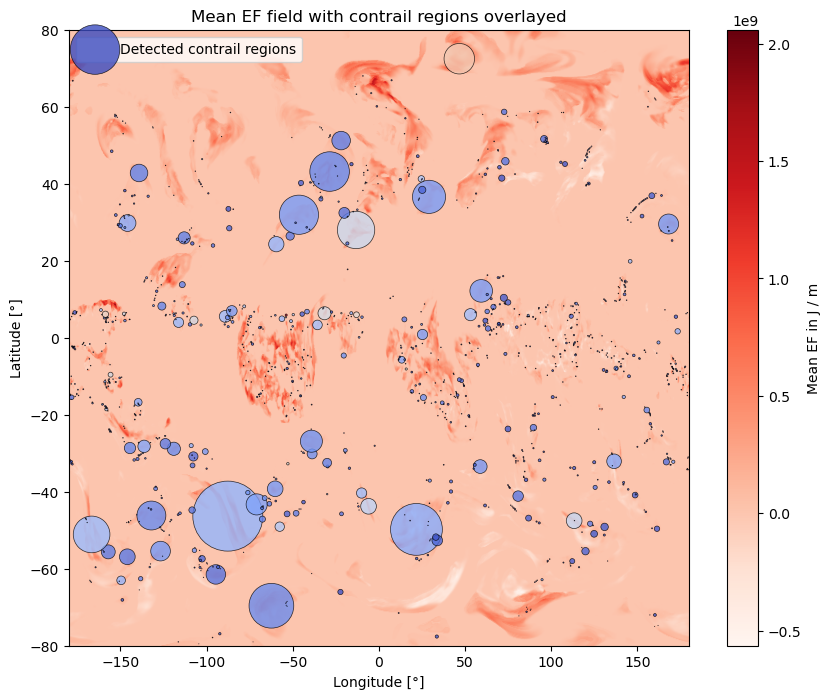

In [99]:

# Assuming ef_per_m has dims (time, latitude, longitude, flight_level)
ef = ds["ef_per_m"]

# --- average over flight levels (and time if present)
ef_mean = ef.mean(dim=[d for d in ef.dims if d in ["flight_level", "time"]])

fig, ax = plt.subplots(figsize=(10, 8))
lon_min, lon_max = ds.longitude.min(), ds.longitude.max()
lat_min, lat_max = ds.latitude.min(), ds.latitude.max()

# --- background: mean forcing field
pcm = ax.imshow(
    ef_mean.T, origin="lower", cmap="Reds",
    extent=[lon_min, lon_max, lat_min, lat_max],
    aspect="auto"
)

cbar = plt.colorbar(pcm, ax=ax, label="Mean EF in J / m")

# --- overlay: region centroids
sc = ax.scatter(
    df["mean_lon"], df["mean_lat"],
    s=df["area_km2"] / 3e3,   # bubble size scaled to area
    c=df["mean_forcing"], cmap="coolwarm", edgecolor="k", linewidth=0.5,
    alpha=0.8, label="Detected contrail regions"
)

ax.set_xlabel("Longitude [°]")
ax.set_ylabel("Latitude [°]")
ax.set_title("Mean EF field with contrail regions overlayed")
ax.legend()
plt.show()



## 3. Analyse contrail-sensitive region thickness

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Load and prepare data ---
file_path = "data/issr/contrail_region_details_2024.csv"
df = pd.read_csv(file_path, parse_dates=["time"])

# Convert thickness from meters to feet
df["thickness_ft"] = df["thickness_m"] * 3.28084  # 1 m = 3.28084 ft

# Optional: filter out non-physical or missing values
df = df[df["thickness_ft"] > 0]

# --- Compute cumulative fraction (CDF) ---
thickness_sorted = np.sort(df["thickness_ft"].values)
fraction = np.arange(1, len(thickness_sorted) + 1) / len(thickness_sorted) * 100  # percent


In [37]:

# --- Simplify while retaining step shape ---
mask = np.r_[True, np.abs(np.diff(thickness_sorted)) > 1e-4]  # detect where it changes
change_indices = np.where(mask)[0]

# We also want to keep the point before each change, if possible
keep_indices = np.unique(np.r_[change_indices, change_indices - 1])
keep_indices = keep_indices[(keep_indices >= 0) & (keep_indices < len(fraction))]

thickness_steps = thickness_sorted[keep_indices]
fraction_steps = fraction[keep_indices]

df_paul = pd.read_csv("data/issr/ISSR and PCR depth distribution.csv")

# --- Convert your simplified arrays into a DataFrame ---
df_steps = pd.DataFrame({
    "Thickness": thickness_steps,
    "80th-percentile contrail regions (+5e8 J/m)": fraction_steps
})

# --- Merge with df_paul ---
# Outer join on 'Thickness' keeps all unique thickness values from both DataFrames
df_merged = pd.merge(df_paul, df_steps, on="Thickness", how="outer")

# --- Sort by thickness for clarity ---
df_merged = df_merged.sort_values("Thickness").reset_index(drop=True)

df_merged.to_csv("output/issr/2_issr_depth_distribution.csv", index=False)
# --- Preview result ---
print(df_steps)

       Thickness  80th-percentile contrail regions (+5e8 J/m)
0    1000.000032                                     0.000072
1    1000.000032                                    77.060210
2    2000.000064                                    77.060283
3    2000.000064                                    88.046288
4    3000.000096                                    88.046360
5    3000.000096                                    93.146060
6    4000.000128                                    93.146132
7    4000.000128                                    95.805446
8    5000.000160                                    95.805518
9    5000.000160                                    97.424294
10   6000.000192                                    97.424366
11   6000.000192                                    98.440242
12   7000.000224                                    98.440314
13   7000.000224                                    99.076628
14   8000.000256                                    99.076701
15   800

C:\Users\TE\AppData\Local\Temp\ipykernel_101688\2755697113.py:22: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  df_merged = pd.merge(df_paul, df_steps, on="Thickness", how="outer")


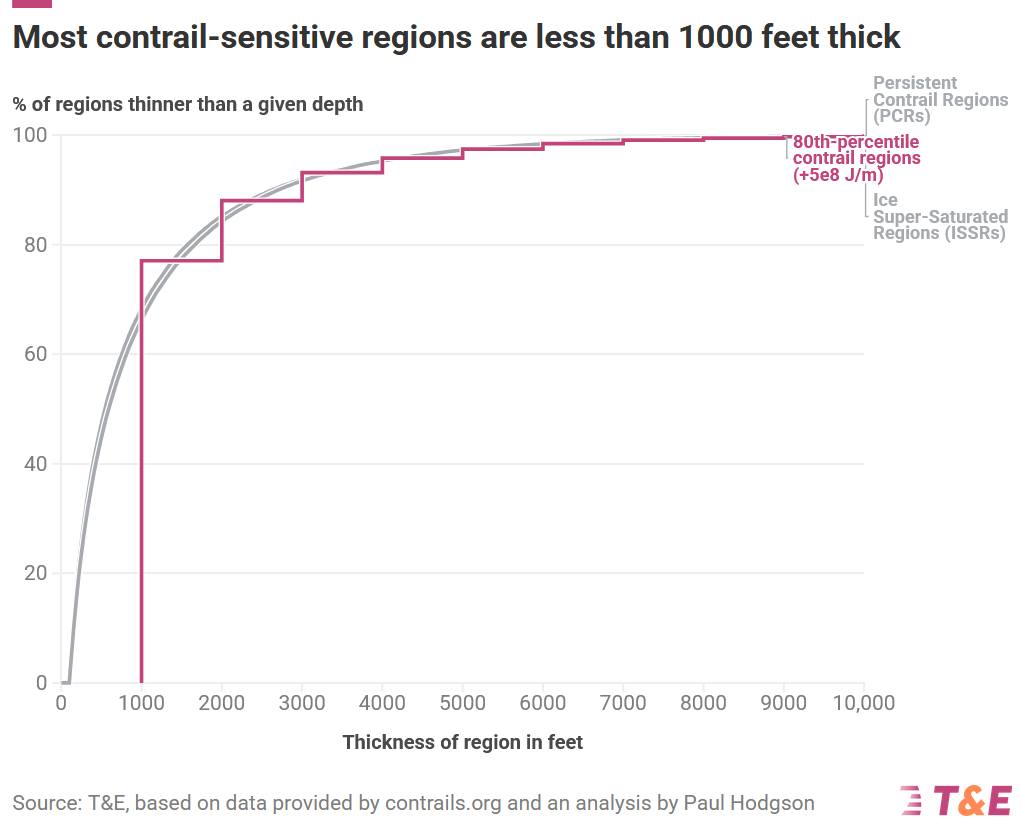

## Output contrail region sample

In [ ]:
file_path = "data/issr/contrail_region_details_2024.csv"
df = pd.read_csv(file_path, parse_dates=["time"]).sample(2_000)
df.to_csv("output/issr/3_contrail_region_sample.csv")

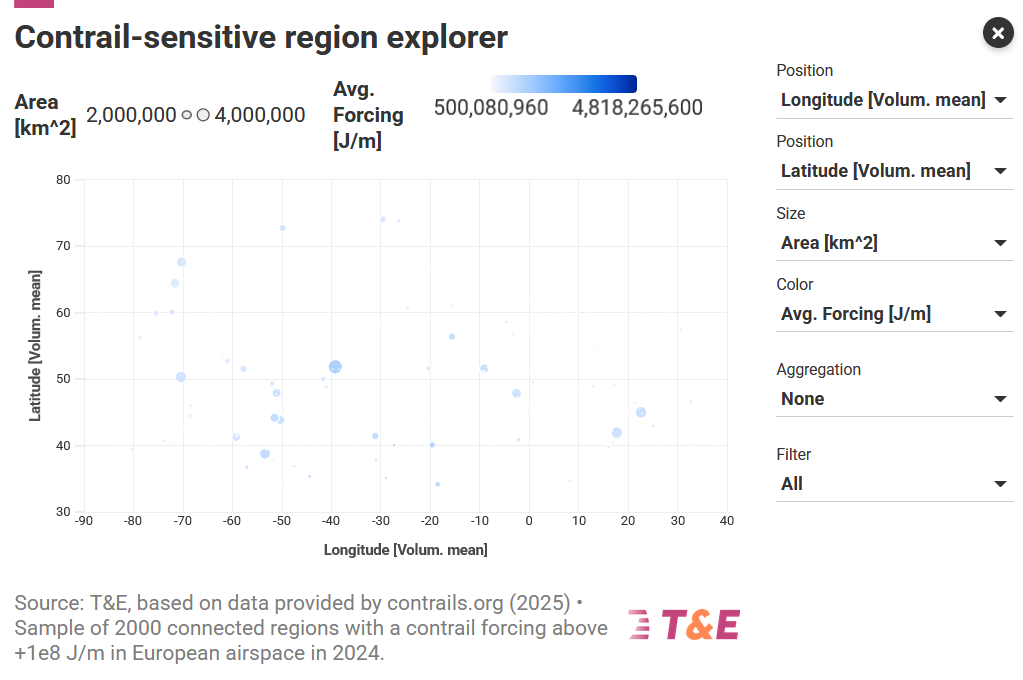